In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
from fbm import FBM
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.optimize import curve_fit
import scipy.special as sp
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from scipy.special import gamma,beta
font = {'size': 30, 'weight':'normal'}
plt.rc('font', **font)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "text.latex.preamble": r"\usepackage{amssymb}",
})
rng = np.random.default_rng(seed=42)
colors = [['blue',"slateblue"], ['darkgoldenrod', "goldenrod"], ['olivedrab', "yellowgreen"], ['red', "indianred",], ['plum',"pink"], ['black','dimgray'], ['orangered','coral'] ]

# SATW Figures

220000
220000
220000


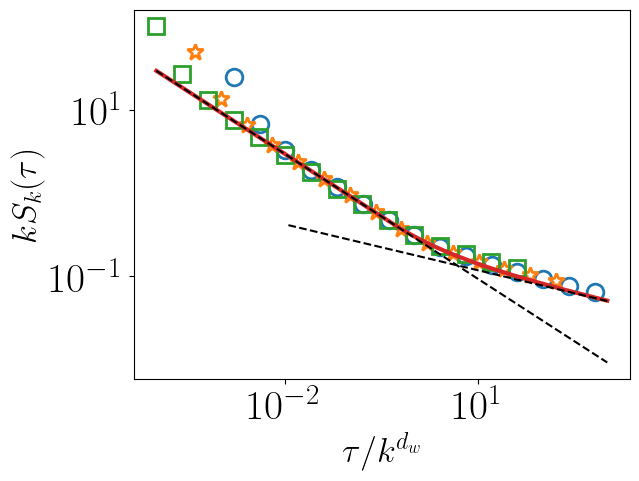

In [2]:
dw=2
beta=1
phi = 1/np.e
theta=np.exp(-beta)/2
i=0
Marker=['o','*','s']
fig,ax=plt.subplots(1,1)
for x0 in [25,50,100]:
    Times=np.logspace(0,6,16)[:-1]
    Ti=[]
    for s in os.listdir('Data/SATRW_1e6/'+str(x0)):
        Ti+=list(np.load('Data/SATRW_1e6/'+str(x0)+'/'+s))
    print(len(Ti))
    Ti=np.array(Ti)
    Ti=Ti[Ti>0]
    Sl=np.array([np.sum(Ti>=ti)/len(Ti) for ti in Times])
    plt.plot(Times/x0**dw,x0*Sl,Marker[i],markersize=12,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0)
    #if i==2:
        #plt.plot(Times/x0**dw,(Times/Times[len(Times)//4])**(-1/dw)*Sl[len(Times)//4]*x0,'--r',linewidth=4)
    #if i==0:
        #plt.plot(Times[len(Times)//4:]/x0**dw,(Times[len(Times)//4:]/Times[len(Times)//4*3])**(-theta)*Sl[len(Times)//4*3]*x0,'--k',linewidth=4)
    i+=1




s_th = np.loadtxt('Data/s-phi0.367879.csv')
tau_th = np.loadtxt('Data/tau-phi0.367879.csv')

asymp_largex = (2/tau_th)**(phi/2) * sp.gamma((1+phi)/2) / (np.sqrt(np.pi) * sp.beta(phi,phi))
asymp_smallx = phi * np.sqrt(2/np.pi/tau_th)

plt.plot(tau_th,s_th,linewidth=3)
plt.plot(tau_th[tau_th>.01], asymp_largex[tau_th>.01], '--k')
plt.plot(tau_th, asymp_smallx, '--k')
plt.semilogx()
plt.semilogy()


plt.xlabel(r'$\tau/k^{d_w}$',fontsize=25)
plt.ylabel(r'$k S_k(\tau)$',fontsize=25)
plt.savefig('Figures/SATW_phiem1.pdf', dpi=600,bbox_inches='tight')

plt.show()

20000
20000
20000


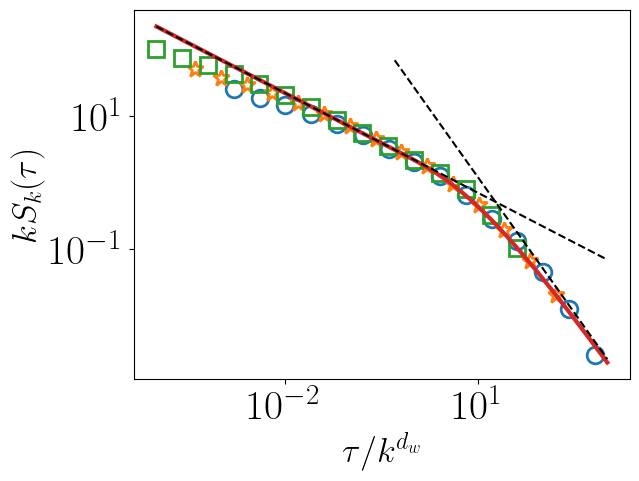

In [3]:
dw=2
phi = np.e
beta=-1
theta=np.exp(-beta)/2
i=0
Marker=['o','*','s']
fig,ax=plt.subplots(1,1)

for x0 in [25,50,100]:
    Times=np.logspace(0,6,16)[:-1]
    Ti=[]
    for s in os.listdir('Data/SATRW_m1_1e6/'+str(x0)):
        Ti+=list(np.load('Data/SATRW_m1_1e6/'+str(x0)+'/'+s))
    print(len(Ti))
    Ti=np.array(Ti)
    Ti=Ti[Ti>0]
    Sl=np.array([np.sum(Ti>=ti)/len(Ti) for ti in Times])
    plt.plot(Times/x0**dw,x0*Sl,Marker[i],markersize=12,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0)
    # if i==2:
    #     Ti=np.logspace(0,7,10)
    #     plt.plot(Ti/x0**dw,(Ti/Times[len(Times)//4])**(-1/dw)*Sl[len(Times)//4]*x0,'--r',linewidth=4)
    # if i==0:
    #     Ti=np.logspace(2,6,10)
    #     plt.plot(Ti/x0**dw,(Ti/Times[len(Times)//4*3+2])**(-theta)*Sl[len(Times)//4*3+2]*x0,'--k',linewidth=4)
    i+=1

s_th = np.loadtxt('Data/s-phiE.csv')
tau_th = np.loadtxt('Data/tau-phiE.csv')

plt.plot(tau_th,s_th,linewidth=3)
asymp_largex = (2/tau_th)**(phi/2) * sp.gamma((1+phi)/2) / (np.sqrt(np.pi) * sp.beta(phi,phi))
asymp_smallx = phi * np.sqrt(2/np.pi/tau_th)

plt.plot(tau_th[tau_th>.5], asymp_largex[tau_th>.5], '--k')
plt.plot(tau_th, asymp_smallx, '--k')
plt.xlabel(r'$\tau/k^{d_w}$',fontsize=25)
plt.ylabel(r'$k S_k(\tau)$',fontsize=25)
ax.loglog()
#ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.savefig('Figures/SATW_phie.pdf', dpi=600,bbox_inches='tight')

plt.show()